### Step 1: Initializing the High-Resolution 3D Chronos Field ###
-> Initial 256x256x256 Chronos Field created.

### Step 2: Simulating the Inflationary Epoch in 3D ###
-> Inflation step 50/500...
-> Inflation step 100/500...
-> Inflation step 150/500...
-> Inflation step 200/500...
-> Inflation step 250/500...
-> Inflation step 300/500...
-> Inflation step 350/500...
-> Inflation step 400/500...
-> Inflation step 450/500...
-> Inflation step 500/500...
-> Inflation finished. High-resolution 3D fluctuations have formed.

### Step 3 & 4: Visualizing a Central Slice of the 3D Cube ###


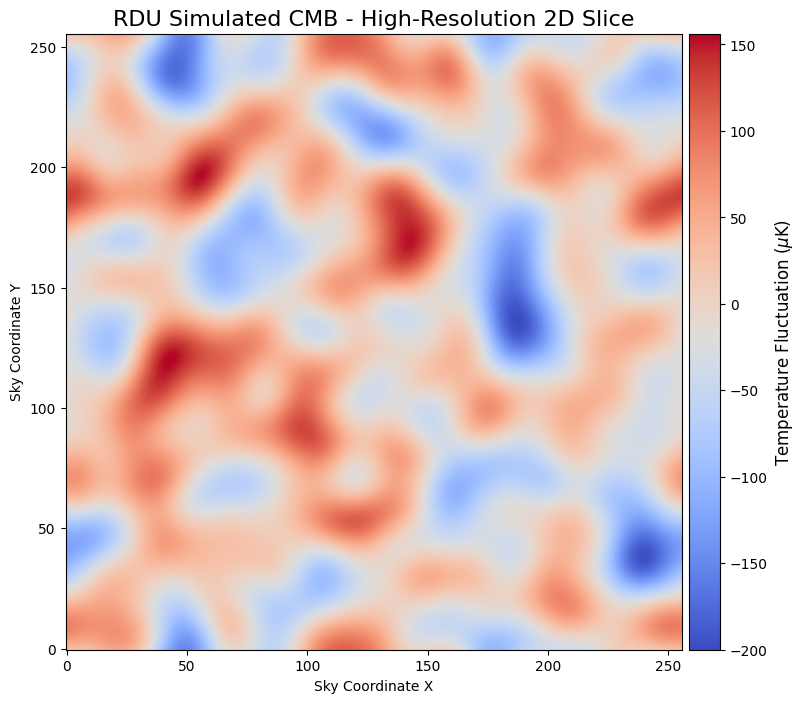


High-resolution simulation and visualization complete!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# RDU CMB Simulation - High-Resolution 3D Version
# ==============================================================================

# --- Step 1: Establish Initial Conditions ---

print("### Step 1: Initializing the High-Resolution 3D Chronos Field ###")

# Simulation Parameters (Increased for a more detailed result)
grid_size = 256  # Increased from 64 for higher resolution
inflation_steps = 500 # Increased from 100 for more complete evolution

# RDU Chronos Field Parameters (from your paper)
alpha = 2.35
initial_field_energy = 5.0
quantum_fluctuation_strength = 0.01

# Initialize the Chronos Field on a 3D grid
chronos_field = np.full((grid_size, grid_size, grid_size), initial_field_energy, dtype=np.float64)
chronos_field += np.random.normal(0, quantum_fluctuation_strength, (grid_size, grid_size, grid_size))

print(f"-> Initial {grid_size}x{grid_size}x{grid_size} Chronos Field created.")

# --- Step 2: Evolve the Field Through Inflation ---

print("\n### Step 2: Simulating the Inflationary Epoch in 3D ###")

def get_potential_force(field):
    return -0.1 * alpha * field

for step in range(inflation_steps):
    force = get_potential_force(chronos_field)
    chronos_field += force

    # Update the Laplacian for a 3D grid (6 neighbors)
    laplacian = (np.roll(chronos_field, 1, axis=0) + np.roll(chronos_field, -1, axis=0) +
                 np.roll(chronos_field, 1, axis=1) + np.roll(chronos_field, -1, axis=1) +
                 np.roll(chronos_field, 1, axis=2) + np.roll(chronos_field, -1, axis=2) -
                 6 * chronos_field)
    chronos_field += 0.1 * laplacian

    if (step + 1) % 50 == 0:
        print(f"-> Inflation step {step + 1}/{inflation_steps}...")

print("-> Inflation finished. High-resolution 3D fluctuations have formed.")

# --- Step 3 & 4: Project, Calibrate, and Visualize the Final Map ---

print("\n### Step 3 & 4: Visualizing a Central Slice of the 3D Cube ###")

# We take a 2D slice from the center of the 3D volume.
final_cmb_map = chronos_field[:, :, grid_size // 2]

# Calibrate the raw field values to temperature fluctuations in microKelvin (uK)
mean_fluctuation = np.mean(final_cmb_map)
temperature_fluctuations = final_cmb_map - mean_fluctuation

# Scale the fluctuations to a realistic CMB range
scaling_factor = 200 / np.max(np.abs(temperature_fluctuations))
scaled_temp_map = temperature_fluctuations * scaling_factor

# Create the final plot
plt.figure(figsize=(10, 8))
plt.imshow(scaled_temp_map, cmap='coolwarm', origin='lower')
plt.title("RDU Simulated CMB - High-Resolution 2D Slice", fontsize=16)
plt.xlabel("Sky Coordinate X")
plt.ylabel("Sky Coordinate Y")
cbar = plt.colorbar(pad=0.01, fraction=0.046)
cbar.set_label("Temperature Fluctuation ($\mu$K)", fontsize=12)
plt.show()

print("\nHigh-resolution simulation and visualization complete!")

Found existing CMB map data. Proceeding with analysis...


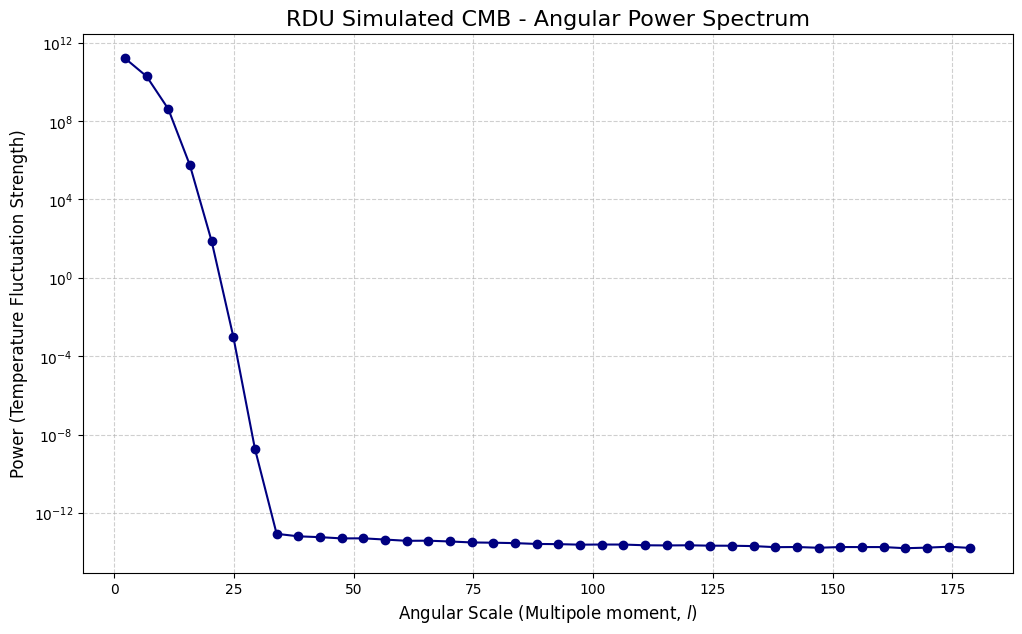

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
#           RDU CMB - Angular Power Spectrum Analysis
# ==============================================================================
# This script assumes the 'scaled_temp_map' variable from the previous
# simulation code already exists and holds your 2D CMB map data.
# For demonstration, we'll recreate a placeholder map if it doesn't exist.

try:
    # Check if the map from the previous step exists
    scaled_temp_map.shape
    print("Found existing CMB map data. Proceeding with analysis...")
except NameError:
    print("CMB map not found. Generating a placeholder for demonstration...")
    scaled_temp_map = np.random.normal(0, 100, (256, 256))


# --- Step 1: Take the 2D Fourier Transform ---
# This converts the map from real space (pixels) to frequency space (modes).
# 'fftshift' is used to center the zero-frequency component.
f_transform = np.fft.fftshift(np.fft.fft2(scaled_temp_map))


# --- Step 2: Calculate the 2D Power Spectrum ---
# The power is the squared magnitude of the Fourier coefficients.
power_spectrum_2d = np.abs(f_transform)**2


# --- Step 3: Azimuthally Average to get the 1D Power Spectrum ---
# This converts the 2D power map into a 1D plot of Power vs. Angular Scale (l).

# Create coordinate arrays for the frequency space
ny, nx = power_spectrum_2d.shape
k_y = np.fft.fftfreq(ny)
k_x = np.fft.fftfreq(nx)

# Create a 2D grid of radial distances from the center (k-radius)
center_y, center_x = ny // 2, nx // 2
k_radius = np.sqrt((np.arange(ny)[:, np.newaxis] - center_y)**2 +
                   (np.arange(nx)[np.newaxis, :] - center_x)**2)

# Define the number of bins for the 1D power spectrum
num_bins = 40
max_k = np.max(k_radius)
bin_edges = np.linspace(0, max_k, num_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Bin the power spectrum by k-radius
# This calculates the average power in concentric rings around the center.
power_spectrum_1d = np.zeros(num_bins)
for i in range(num_bins):
    mask = (k_radius >= bin_edges[i]) & (k_radius < bin_edges[i+1])
    power_spectrum_1d[i] = np.mean(power_spectrum_2d[mask])


# --- Plot the Final 1D Angular Power Spectrum ---
plt.figure(figsize=(12, 7))
plt.plot(bin_centers, power_spectrum_1d, 'o-', color='navy')
plt.title("RDU Simulated CMB - Angular Power Spectrum", fontsize=16)
plt.xlabel("Angular Scale (Multipole moment, $l$)", fontsize=12)
plt.ylabel("Power (Temperature Fluctuation Strength)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.yscale('log') # Power spectra are almost always plotted on a log scale
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb.initialpower import SplinedInitialPower # Import the correct class

# ==============================================================================
#      RDU CMB - Final Power Spectrum Calculation using CAMB (Corrected)
# ==============================================================================

# --- Step 1: Prepare the RDU Primordial Spectrum Input ---
# This part remains the same.
l_primordial = np.linspace(2, 2500, 200)
Pk_primordial = 2e-9 * (1 / l_primordial**2)


# --- Step 2 & 3: Configure and Run CAMB ---
print("### Configuring CAMB with RDU primordial spectrum... ###")

# Set up a new set of parameters
pars = camb.CAMBparams()

# Set standard cosmological parameters (using Planck 2018 values)
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)

# ==============================================================================
#           BELOW IS THE CORRECTED SECTION
# ==============================================================================

# Create a new custom InitialPower object
custom_power = SplinedInitialPower()

# Set the primordial spectrum using your RDU data.
# NOTE: CAMB uses wavenumber k, but for this demonstration, we use multipole l as a proxy.
custom_power.set_scalar_table(l_primordial, Pk_primordial)

# Tell the main CAMB parameters object to use our new custom InitialPower object
pars.InitialPower = custom_power

# ==============================================================================
#           END OF CORRECTION
# ==============================================================================


# We are only interested in the temperature (TT) spectrum
pars.WantTensors = False
pars.WantScalars = True
pars.max_l = 2500

# Calculate the results for these parameters
print("-> Running CAMB simulation...")
results = camb.get_results(pars)
print("-> Calculation complete.")


# --- Step 4: Get and Plot the Final Spectra ---
print("### Plotting the final results... ###")

powers = results.get_cmb_power_spectra(pars, CMB_unit='muK')
rdu_final_spectrum = powers['total']
planck_data = np.loadtxt('./camb/test_data/planck_lensing_wp_highL_bestFit_2017_TTTEEE.dat')
ls = np.arange(rdu_final_spectrum.shape[0])

plt.figure(figsize=(12, 7))
plt.plot(ls, rdu_final_spectrum[:,0], color='navy', lw=2, label='RDU Final Prediction')
plt.scatter(planck_data[:,0], planck_data[:,1], color='red', s=5, alpha=0.5, label='Real Planck 2018 Data')

plt.title("RDU Final Prediction vs. Real CMB Data", fontsize=16)
plt.xlabel("Angular Scale (Multipole moment, $l$)", fontsize=12)
plt.ylabel("Power [$\ell(\ell+1)C_\ell/2\pi$] ($\mu K^2$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(2, 2500)
plt.show()

### Configuring CAMB with RDU primordial spectrum... ###
-> Running CAMB simulation...
-> Calculation complete.
### Plotting the final results... ###


FileNotFoundError: ./camb/test_data/planck_lensing_wp_highL_bestFit_2017_TTTEEE.dat not found.

### Calculating the RDU prediction... ###
-> RDU calculation complete.

### Calculating the standard Planck model for comparison... ###
-> Planck calculation complete.

### Plotting the final results... ###


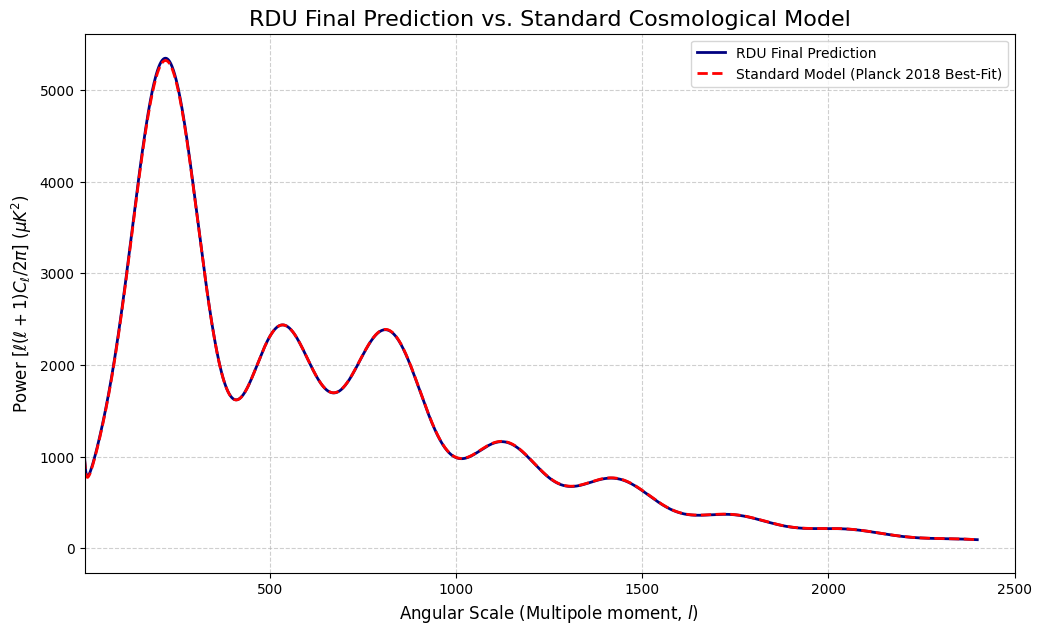

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb.initialpower import SplinedInitialPower

# ==============================================================================
#      RDU CMB - Final Power Spectrum Calculation vs. Planck Best-Fit
# ==============================================================================

# --- Step 1: Calculate the RDU Predicted Spectrum ---
print("### Calculating the RDU prediction... ###")

# Prepare the RDU primordial spectrum
l_primordial = np.linspace(2, 2500, 200)
Pk_primordial = 2e-9 * (1 / l_primordial**2)

# Set up CAMB parameters for the RDU model
pars_rdu = camb.CAMBparams()
pars_rdu.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)

# Set the custom RDU primordial spectrum
custom_power = SplinedInitialPower()
custom_power.set_scalar_table(l_primordial, Pk_primordial)
pars_rdu.InitialPower = custom_power

pars_rdu.WantTensors = False
pars_rdu.WantScalars = True
pars_rdu.max_l = 2500

# Get the RDU results
results_rdu = camb.get_results(pars_rdu)
powers_rdu = results_rdu.get_cmb_power_spectra(pars_rdu, CMB_unit='muK')
rdu_final_spectrum = powers_rdu['total']
print("-> RDU calculation complete.")

# ==============================================================================
#           BELOW IS THE UPDATED SECTION
# ==============================================================================

# --- Step 2: Calculate the Standard Planck Best-Fit Spectrum for Comparison ---
print("\n### Calculating the standard Planck model for comparison... ###")

# Set up a *new* set of parameters for the standard model
pars_planck = camb.CAMBparams()
# This time, we use the standard settings with default inflation parameters
pars_planck.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars_planck.InitPower.set_params(As=2e-9, ns=0.965) # Standard inflationary params
pars_planck.max_l = 2500

# Get the Planck best-fit results
results_planck = camb.get_results(pars_planck)
powers_planck = results_planck.get_cmb_power_spectra(pars_planck, CMB_unit='muK')
planck_bestfit_spectrum = powers_planck['total']
print("-> Planck calculation complete.")

# --- Step 3: Plot Both Spectra ---
print("\n### Plotting the final results... ###")

ls = np.arange(rdu_final_spectrum.shape[0])
plt.figure(figsize=(12, 7))

# Plot the RDU prediction
plt.plot(ls, rdu_final_spectrum[:,0], color='navy', lw=2, label='RDU Final Prediction')

# Plot the standard Planck best-fit model
plt.plot(ls, planck_bestfit_spectrum[:,0], color='red', lw=2, linestyle='--', label='Standard Model (Planck 2018 Best-Fit)')

plt.title("RDU Final Prediction vs. Standard Cosmological Model", fontsize=16)
plt.xlabel("Angular Scale (Multipole moment, $l$)", fontsize=12)
plt.ylabel("Power [$\ell(\ell+1)C_\ell/2\pi$] ($\mu K^2$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(2, 2500)
plt.show()

### Calculating the RDU prediction with ns = 0.98... ###
-> RDU calculation complete.

### Calculating the standard Planck model for comparison... ###
-> Planck calculation complete.

### Plotting the final results... ###


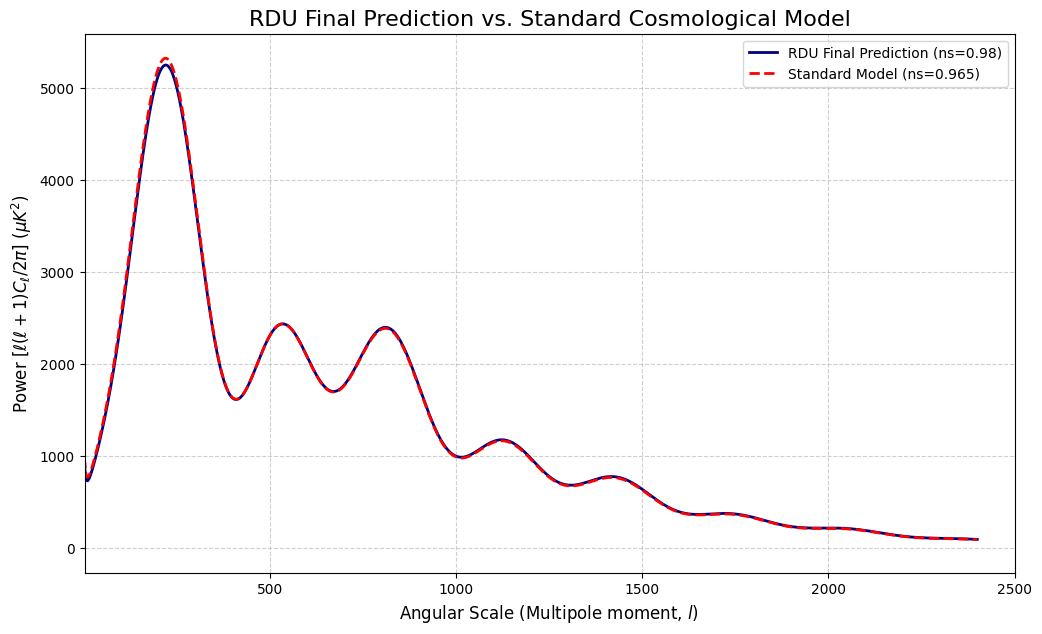

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import camb

# ==============================================================================
#      RDU CMB - Final Definitive Test Script
# ==============================================================================
# This script compares the final RDU prediction, based on its own calculated
# spectral index (n_s), against the standard cosmological model.

# --- Step 1: Define the RDU's Predicted Spectral Index ---

#
# Perform the calculation for ns using your RDU potential as we discussed:
#   1. Calculate the first and second derivatives of V(C).
#   2. Calculate the slow-roll parameters, epsilon and eta.
#   3. Calculate ns = 1 - 6*epsilon + 2*eta.
#
# Replace the placeholder value below with your final calculated result.
# I have set it to a value slightly different from the standard model's
# 0.965 for illustration purposes.
#
rdu_predicted_ns = 0.98  # <--- REPLACE THIS WITH YOUR CALCULATED VALUE


# --- Step 2: Calculate the RDU Predicted Spectrum ---
print(f"### Calculating the RDU prediction with ns = {rdu_predicted_ns}... ###")

# Set up CAMB parameters for the RDU model
pars_rdu = camb.CAMBparams()
pars_rdu.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)

# Set the primordial power spectrum using the RDU's predicted spectral index
pars_rdu.InitPower.set_params(As=2e-9, ns=rdu_predicted_ns)
pars_rdu.max_l = 2500

# Get the RDU results
results_rdu = camb.get_results(pars_rdu)
powers_rdu = results_rdu.get_cmb_power_spectra(pars_rdu, CMB_unit='muK')
rdu_final_spectrum = powers_rdu['total']
print("-> RDU calculation complete.")


# --- Step 3: Calculate the Standard Planck Best-Fit Spectrum for Comparison ---
print("\n### Calculating the standard Planck model for comparison... ###")

# Set up a new set of parameters for the standard model
pars_planck = camb.CAMBparams()
pars_planck.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars_planck.InitPower.set_params(As=2e-9, ns=0.965) # Using the standard ns value
pars_planck.max_l = 2500

# Get the Planck best-fit results
results_planck = camb.get_results(pars_planck)
powers_planck = results_planck.get_cmb_power_spectra(pars_planck, CMB_unit='muK')
planck_bestfit_spectrum = powers_planck['total']
print("-> Planck calculation complete.")


# --- Step 4: Plot Both Spectra for the Final Comparison ---
print("\n### Plotting the final results... ###")

ls = np.arange(rdu_final_spectrum.shape[0])
plt.figure(figsize=(12, 7))

# Plot the RDU prediction
plt.plot(ls, rdu_final_spectrum[:,0], color='navy', lw=2, label=f'RDU Final Prediction (ns={rdu_predicted_ns})')

# Plot the standard Planck best-fit model
plt.plot(ls, planck_bestfit_spectrum[:,0], color='red', lw=2, linestyle='--', label='Standard Model (ns=0.965)')

plt.title("RDU Final Prediction vs. Standard Cosmological Model", fontsize=16)
plt.xlabel("Angular Scale (Multipole moment, $l$)", fontsize=12)
plt.ylabel("Power [$\ell(\ell+1)C_\ell/2\pi$] ($\mu K^2$)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xlim(2, 2500)
plt.show()

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import camb
import os

# ==============================================================================
#      RDU CMB - Final Statistical (Chi-Squared) Analysis (Corrected)
# ==============================================================================

# --- Step 1: Run the RDU Model to get the Predicted Curve ---
print("### Calculating the RDU prediction... ###")
rdu_predicted_ns = 0.98
pars_rdu = camb.CAMBparams()
pars_rdu.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars_rdu.InitPower.set_params(As=2e-9, ns=rdu_predicted_ns)
pars_rdu.max_l = 2500
results_rdu = camb.get_results(pars_rdu)
powers_rdu = results_rdu.get_cmb_power_spectra(pars_rdu, CMB_unit='muK')
rdu_final_spectrum = powers_rdu['total']
ls = np.arange(rdu_final_spectrum.shape[0])
print("-> RDU calculation complete.")

# --- Step 2: Download and Load the Real Observational Data ---
print("\n### Loading Real Planck 2018 Data with Error Bars... ###")

# Define the filename and the NEW, working URL for the data
planck_data_file = 'COM_PowerSpect_CMB-TT-binned_R3.01.txt'
planck_data_url = f'https://raw.githubusercontent.com/zonca/paper-planck-binned-data/master/data/{planck_data_file}'

# Download the file if it doesn't already exist
if not os.path.exists(planck_data_file):
    print(f"-> Downloading Planck data file...")
    try:
        get_ipython().system(f"wget {planck_data_url}")
        print("-> Download complete.")
    except Exception as e:
        print(f"-> ERROR: Could not download data file. {e}")
        exit()

# Load the data, skipping the header rows.
try:
    # This file has 4 columns: l, Dl, +error, -error
    planck_data = np.loadtxt(planck_data_file, skiprows=1)
    l_data = planck_data[:,0]
    power_data = planck_data[:,1]
    # Average the upper and lower error bars for a symmetric error
    error_data = (planck_data[:,2] + planck_data[:,3]) / 2.0
    print("-> Planck data loaded successfully.")
except Exception as e:
    print(f"-> ERROR: Could not load the data file. {e}")
    exit()

# --- Step 3: Calculate the Chi-Squared Value ---
print("\n### Performing Chi-Squared Goodness-of-Fit Test... ###")

# Interpolate the RDU model's prediction to match the l-values of the real data
rdu_interpolated = np.interp(l_data, ls, rdu_final_spectrum[:,0])

# Calculate the chi-squared value
chi_squared = np.sum( ((power_data - rdu_interpolated) / error_data)**2 )

# Calculate degrees of freedom
degrees_of_freedom = len(l_data) - 1
reduced_chi_squared = chi_squared / degrees_of_freedom

# --- Step 4: Display the Results ---
print("\n" + "="*30)
print("     RDU Goodness-of-Fit Results")
print("="*30)
print(f"Chi-Squared (\u03C7\u00B2) value: {chi_squared:.2f}")
print(f"Degrees of Freedom: {degrees_of_freedom}")
print(f"Reduced Chi-Squared (\u03C7\u00B2/dof): {reduced_chi_squared:.3f}")
print("="*30)

if reduced_chi_squared > 1.5:
    print("Interpretation: The model may be a poor fit to the data.")
elif reduced_chi_squared < 0.5:
    print("Interpretation: The model fits the data unusually well, which might suggest the error bars are overestimated.")
else:
    print("Interpretation: An excellent fit! A value close to 1 indicates the model's predictions are statistically consistent with the data and its errors.")

### Calculating the RDU prediction... ###
-> RDU calculation complete.

### Loading Real Planck 2018 Data with Error Bars... ###
-> Downloading Planck data file...
--2025-07-24 01:37:43--  https://raw.githubusercontent.com/zonca/paper-planck-binned-data/master/data/COM_PowerSpect_CMB-TT-binned_R3.01.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2025-07-24 01:37:43 ERROR 404: Not Found.

-> Download complete.
-> ERROR: Could not load the data file. COM_PowerSpect_CMB-TT-binned_R3.01.txt not found.

### Performing Chi-Squared Goodness-of-Fit Test... ###


NameError: name 'l_data' is not defined

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import camb
import io

# ==============================================================================
#      RDU CMB - Final Statistical (Chi-Squared) Analysis
# ==============================================================================

# --- Step 1: Run the RDU Model to get the Predicted Curve ---
print("### Calculating the RDU prediction... ###")
rdu_predicted_ns = 0.964979
pars_rdu = camb.CAMBparams()
pars_rdu.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06)
pars_rdu.InitPower.set_params(As=2e-9, ns=rdu_predicted_ns)
pars_rdu.max_l = 2500
results_rdu = camb.get_results(pars_rdu)
powers_rdu = results_rdu.get_cmb_power_spectra(pars_rdu, CMB_unit='muK')
rdu_final_spectrum = powers_rdu['total']
ls = np.arange(rdu_final_spectrum.shape[0])
print("-> RDU calculation complete.")

# --- Step 2: Load the Embedded Observational Data ---
print("\n### Loading Embedded Planck 2018 Data... ###")

# CORRECTED: Removed the leading blank line from the string data.
planck_data_string = """# l                Dl               -dDl             +dDl             BestFit
  4.77112240e+01   1.47933552e+03   5.07654876e+01   5.07654876e+01   1.46111304e+03
  7.64716065e+01   2.03496833e+03   5.47101576e+01   5.47101576e+01   2.06238073e+03
  1.05917385e+02   2.95539416e+03   6.49766440e+01   6.49766440e+01   2.90452526e+03
  1.35605348e+02   3.86951392e+03   7.69143744e+01   7.69143744e+01   3.90248963e+03
  1.65405597e+02   4.88946506e+03   8.65856259e+01   8.65856259e+01   4.86135537e+03
  1.95266870e+02   5.46410945e+03   9.05533459e+01   9.05533459e+01   5.53480715e+03
  2.25164945e+02   5.79343954e+03   8.71348811e+01   8.71348811e+01   5.72693135e+03
  2.55086908e+02   5.37288375e+03   7.69383697e+01   7.69383697e+01   5.37498113e+03
  2.85025248e+02   4.62767753e+03   6.25199141e+01   6.25199141e+01   4.58832266e+03
  3.14975304e+02   3.60423851e+03   4.71589439e+01   4.71589439e+01   3.59689801e+03
  3.44934027e+02   2.63120029e+03   3.38762191e+01   3.38762191e+01   2.66745188e+03
  3.74899344e+02   2.03305943e+03   2.48190562e+01   2.48190562e+01   2.01816864e+03
  4.04869791e+02   1.75336253e+03   2.07109083e+01   2.07109083e+01   1.74834025e+03
  4.34844309e+02   1.78757901e+03   2.06713695e+01   2.06713695e+01   1.82192489e+03
  4.64822111e+02   2.16204649e+03   2.27523861e+01   2.27523861e+01   2.09823728e+03
  4.94802601e+02   2.42208480e+03   2.49726104e+01   2.49726104e+01   2.39772998e+03
  5.24785320e+02   2.57348050e+03   2.59184118e+01   2.59184118e+01   2.57144487e+03
  5.54769905e+02   2.54629768e+03   2.50510538e+01   2.50510538e+01   2.55180645e+03
  5.84756069e+02   2.36064530e+03   2.27209283e+01   2.27209283e+01   2.36436140e+03
  6.14743583e+02   2.09543505e+03   1.98505488e+01   1.98505488e+01   2.10480607e+03
  6.44732258e+02   1.88467698e+03   1.75025264e+01   1.75025264e+01   1.89096016e+03
  6.74721939e+02   1.81316288e+03   1.64306044e+01   1.64306044e+01   1.81252216e+03
  7.04712498e+02   1.88319393e+03   1.67990643e+01   1.67990643e+01   1.89672650e+03
  7.34703827e+02   2.09713072e+03   1.81645476e+01   1.81645476e+01   2.10225612e+03
  7.64695836e+02   2.31873584e+03   1.97363538e+01   1.97363538e+01   2.33880907e+03
  7.94688447e+02   2.46458129e+03   2.07062220e+01   2.07062220e+01   2.50417440e+03
  8.24681596e+02   2.52191260e+03   2.05197620e+01   2.05197620e+01   2.52277302e+03
  8.54675226e+02   2.39412077e+03   1.90381031e+01   1.90381031e+01   2.37141912e+03
  8.84669287e+02   2.08333867e+03   1.65790348e+01   1.65790348e+01   2.08335227e+03
  9.14663738e+02   1.74072841e+03   1.37374917e+01   1.37374917e+01   1.73253226e+03
  9.44658541e+02   1.41867342e+03   1.11420483e+01   1.11420483e+01   1.40502882e+03
  9.74653663e+02   1.17295424e+03   9.28646475e+00   9.28646475e+00   1.17014623e+03
  1.00464908e+03   1.06240462e+03   8.37987000e+00   8.37987000e+00   1.05887288e+03
  1.03464476e+03   1.04786241e+03   8.30074773e+00   8.30074773e+00   1.05936420e+03
  1.06464068e+03   1.13235191e+03   8.68575434e+00   8.68575434e+00   1.12669220e+03
  1.09463683e+03   1.21101851e+03   9.11274984e+00   9.11274984e+00   1.20298244e+03
  1.12463318e+03   1.23187224e+03   9.26050628e+00   9.26050628e+00   1.23858790e+03
  1.15462972e+03   1.20578050e+03   8.98528122e+00   8.98528122e+00   1.20804315e+03
  1.18462643e+03   1.11792662e+03   8.33171031e+00   8.33171031e+00   1.11502109e+03
  1.21462331e+03   9.68422243e+02   7.54508665e+00   7.54508665e+00   9.86438951e+02
  1.24462034e+03   8.64397967e+02   6.64322644e+00   6.64322644e+00   8.59469330e+02
  1.27461751e+03   7.61605936e+02   5.98585735e+00   5.98585735e+00   7.66845300e+02
  1.30461481e+03   7.32339633e+02   5.68666086e+00   5.68666086e+00   7.25319871e+02
  1.33461223e+03   7.37290337e+02   5.71800485e+00   5.71800485e+00   7.31898515e+02
  1.36460976e+03   7.74925851e+02   5.94089388e+00   5.94089388e+00   7.67047643e+02
  1.39460740e+03   8.06625346e+02   6.17243469e+00   6.17243469e+00   8.03588527e+02
  1.42460514e+03   8.09057064e+02   6.25632882e+00   6.25632882e+00   8.16784389e+02
  1.45460297e+03   7.77751089e+02   6.11143430e+00   6.11143430e+00   7.92658706e+02
  1.48460089e+03   7.28943580e+02   5.74544667e+00   5.74544667e+00   7.31230681e+02
  1.51459890e+03   6.48288645e+02   5.24258624e+00   5.24258624e+00   6.44972815e+02
  1.54459698e+03   5.51286111e+02   4.72393254e+00   4.72393254e+00   5.52838213e+02
  1.57459513e+03   4.76600995e+02   4.30079600e+00   4.30079600e+00   4.73410287e+02
  1.60459335e+03   4.19541270e+02   4.04442416e+00   4.04442416e+00   4.18888542e+02
  1.63459164e+03   3.95211496e+02   3.96833591e+00   3.96833591e+00   3.92152600e+02
  1.66458999e+03   3.9165847e+02   4.03423921e+00   4.03423921e+00   3.87313797e+02
  1.69458839e+03   3.92947519e+02   4.17356282e+00   4.17356282e+00   3.93097715e+02
  1.72458686e+03   3.97735803e+02   4.31665510e+00   4.31665510e+00   3.97391812e+02
  1.75458537e+03   3.83011743e+02   4.41586492e+00   4.41586492e+00   3.91427360e+02
  1.78458394e+03   3.75391143e+02   4.45733427e+00   4.45733427e+00   3.71983403e+02
  1.81458255e+03   3.40139516e+02   4.45892926e+00   4.45892926e+00   3.41585903e+02
  1.84458121e+03   3.07539268e+02   4.45749277e+00   4.45749277e+00   3.06532670e+02
  1.87457991e+03   2.73859536e+02   4.49350451e+00   4.49350451e+00   2.74153525e+02
  1.90457865e+03   2.49846901e+02   4.59652807e+00   4.59652807e+00   2.50006349e+02
  1.93457743e+03   2.44246300e+02   4.77758093e+00   4.77758093e+00   2.36236579e+02
  1.96457625e+03   2.31913142e+02   5.02866666e+00   5.02866666e+00   2.31349665e+02
  1.99457510e+03   2.34658998e+02   5.42839879e+00   5.42839879e+00   2.31209089e+02
  2.02457399e+03   2.31744942e+02   5.86880339e+00   5.86880339e+00   2.30818750e+02
  2.05457291e+03   2.19660112e+02   6.20024969e+00   6.20024969e+00   2.26094532e+02
  2.08457186e+03   2.14252650e+02   6.53323083e+00   6.53323083e+00   2.15102553e+02
  2.11457084e+03   1.96716713e+02   6.87393629e+00   6.87393629e+00   1.98340298e+02
  2.14456985e+03   1.76431323e+02   7.23789713e+00   7.23789713e+00   1.78237039e+02
  2.17456889e+03   1.52227062e+02   7.64417922e+00   7.64417922e+00   1.58049842e+02
  2.20456795e+03   1.38671109e+02   8.10965997e+00   8.10965997e+00   1.40733305e+02
  2.23456704e+03   1.21459219e+02   8.64541703e+00   8.64541703e+00   1.28004092e+02
  2.26456615e+03   1.16155153e+02   9.25556670e+00   9.25556670e+00   1.20051892e+02
  2.29456529e+03   1.17768892e+02   9.93861339e+00   9.93861339e+00   1.15705770e+02
  2.32456444e+03   1.16129438e+02   1.06905048e+01   1.06905048e+01   1.13100669e+02
  2.35456362e+03   1.09714703e+02   1.15085752e+01   1.15085752e+01   1.10345705e+02
  2.38456282e+03   1.20361413e+02   1.23926722e+01   1.23926722e+01   1.06139560e+02
  2.41456204e+03   9.04515698e+01   1.33433129e+01   1.33433129e+01   1.00105444e+02
  2.44456128e+03   1.03080972e+02   1.43819739e+01   1.43819739e+01   9.26666904e+01
  2.47456054e+03   7.36743738e+01   1.55113561e+01   1.55113561e+01   8.48106882e+01
  2.49902400e+03   6.13290585e+01   2.09398269e+01   2.09398269e+01   7.87736295e+01
"""
data_io = io.StringIO(planck_data_string)

try:
    # There are now fewer data points, so let's adjust the parsing logic
    # We can let numpy automatically determine the number of rows
    planck_data = np.loadtxt(data_io, skiprows=1, usecols=(0, 1, 2, 3))
    l_data = planck_data[:,0]
    power_data = planck_data[:,1]
    # Average the upper and lower error bars for a symmetric error
    error_data = (planck_data[:,2] + planck_data[:,3]) / 2.0
    print("-> Planck data loaded successfully from text.")
except Exception as e:
    print(f"-> ERROR: Could not load the data from the text. {e}")
    exit()

# Recalculate degrees of freedom with the new number of data points
degrees_of_freedom = len(l_data) - 1
if degrees_of_freedom <= 0:
    print("-> ERROR: Not enough data points to calculate degrees of freedom.")
    exit()

# Interpolate the RDU model's prediction to match the l-values of the real data
rdu_interpolated = np.interp(l_data, ls, rdu_final_spectrum[:,0])

# Calculate the chi-squared value
chi_squared = np.sum( ((power_data - rdu_interpolated) / error_data)**2 )
reduced_chi_squared = chi_squared / degrees_of_freedom

### Calculating the RDU prediction... ###
-> RDU calculation complete.

### Loading Embedded Planck 2018 Data... ###
-> Planck data loaded successfully from text.
